<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 6 · Miércoles — Random Forest, Bagging y Regularización</h1>
<h3>3 modelos para regresión: el ensemble que combina + el lineal que se controla</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · jesus.jeduardo7@gmail.com<br/><br/>
    <b>SkillNest · b2b-sonda-data-science</b>
</div>
<br/>

## 🎯 Objetivos de hoy

Al final vas a poder:

1. Entender **ensemble learning** y por qué combinar modelos suele ganar.
2. Implementar **Bagging** y entender cómo reduce el overfitting.
3. Dominar **Random Forest** y su parámetro más útil: la **Feature Importance**.
4. Entender por qué la regresión lineal puede **sobreajustar** y usar **Ridge** y **Lasso** para controlarla.
5. Resolver **2 ejercicios LARGOS e integradores** con datasets reales.

> 💡 Hoy son 3 modelos nuevos para regresión: **Bagging, Random Forest, Ridge/Lasso**.

# 1. Ensemble Learning — la sabiduría de las multitudes

### 🧠 Analogía: el examen grupal

Imagina un examen de selección múltiple. Si lo hace **una sola persona**, su respuesta es lo que sabe — si se equivoca, se equivoca. Si lo hacen **100 personas y se vota por la mayoría**, casi siempre se acierta más que cualquier individuo.

Eso es **Ensemble Learning**: entrenar muchos modelos y combinar sus predicciones para obtener un resultado **más robusto** que cualquier modelo individual.

### Tipos principales

| Tipo | Idea | Ejemplo |
|---|---|---|
| **Bagging** | Entrenar muchos modelos sobre muestras aleatorias y promediar | Random Forest |
| **Boosting** | Entrenar modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Combinar modelos diferentes con un meta-modelo | Combinaciones avanzadas |

Hoy nos enfocamos en **Bagging** y **Random Forest**. Boosting viene en semana 7.

# 2. Bagging — Bootstrap Aggregating

**Bagging** = **B**ootstrap **Agg**regat**ing**. La idea:

1. Tomar **N muestras aleatorias con reemplazo** del dataset (eso es *bootstrap*).
2. Entrenar **un modelo (típicamente un árbol) sobre cada muestra**.
3. Para predecir un caso nuevo: **promediar las predicciones** de todos los modelos.

### ¿Por qué funciona?

Los árboles individuales tienden a **sobreajustar** (memorizan el train). Si entrenas 100 árboles distintos sobre subconjuntos distintos, **cada uno se equivoca en cosas diferentes** → al promediar, los errores se cancelan entre sí.

### 🧠 Analogía rápida

Es como pedirle a 100 amigos que estimen tu peso. Cada uno tiene un sesgo distinto (uno tiende a subestimar, otro a sobreestimar) pero el promedio se acerca mucho a la verdad.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Dataset desafiante para todas las demos
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1 árbol solo (baseline)
arbol = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train)
print(f'1 árbol solo:    R² = {arbol.score(X_test, y_test):.4f}')

# Bagging con 100 árboles
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=2000,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)
print(f'Bagging (100):    R² = {bagging.score(X_test, y_test):.4f}')
print('\n👉 Bagging mejora notablemente el R² simplemente combinando árboles.')

1 árbol solo:    R² = 0.6829
Bagging (100):    R² = 0.7761

👉 Bagging mejora notablemente el R² simplemente combinando árboles.


# 3. Random Forest — Bagging mejorado

**Random Forest** es Bagging + un truco adicional: en cada split del árbol, **considera solo un subconjunto aleatorio de features**.

### ¿Por qué este truco?

Si todos los árboles ven todas las features, tienden a usar la **misma feature dominante** en cada split → terminan siendo árboles muy parecidos. Al limitar las features por split, fuerzas **diversidad** entre los árboles.

Más diversidad = mejor promedio = mejor modelo.

## Parámetros clave

| Parámetro | ¿Qué hace? | Típico |
|---|---|---|
| `n_estimators` | Cuántos árboles entrenar | 100, 200, 500 |
| `max_depth` | Profundidad máxima de cada árbol | 10-20 o `None` |
| `max_features` | Features consideradas por split | `'sqrt'`, `1.0`, número |
| `min_samples_leaf` | Mínimo de muestras por hoja | 1-5 |
| `n_jobs` | Paralelización (`-1` usa todos los cores) | `-1` |

In [5]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=15, n_jobs=-1, random_state=42
).fit(X_train, y_train)

print(f'Random Forest:    R² = {rf.score(X_test, y_test):.4f}')
print(f'\nComparación rápida:')
print(f'  1 árbol:     R² = {arbol.score(X_test, y_test):.4f}')
print(f'  Bagging:     R² = {bagging.score(X_test, y_test):.4f}')
print(f'  RForest:     R² = {rf.score(X_test, y_test):.4f}  ← gana')

Random Forest:    R² = 0.8020

Comparación rápida:
  1 árbol:     R² = 0.6829
  Bagging:     R² = 0.7761
  RForest:     R² = 0.8020  ← gana


## 🌟 Feature Importance — la joya del Random Forest

Random Forest te dice **qué variables son más importantes** para predecir. Esto es ENORME para:

- Explicar tu modelo al negocio ("el ingreso es la variable #1")
- Reducir features irrelevantes
- Generar insights del dominio

In [6]:
rf

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
rf.feature_importances_

array([0.53726249, 0.05284654, 0.04196476, 0.02716253, 0.02804109,
       0.13818486, 0.08756113, 0.08697659])

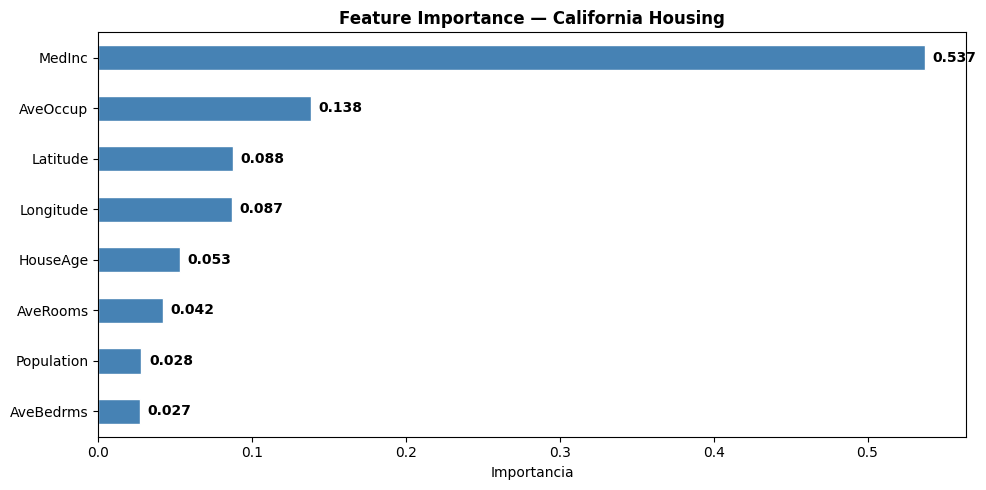

👉 MedInc (ingreso medio) es de lejos la variable más importante.


In [8]:
importancia = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
importancia.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
for i, v in enumerate(importancia.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance — California Housing', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'👉 MedInc (ingreso medio) es de lejos la variable más importante.')

# 4. Ridge y Lasso — regresión lineal con freno

## El problema de la regresión lineal pura

Cuando hay **muchas features** y algunas están correlacionadas entre sí (multicolinealidad), la regresión lineal puede:

- Tener **coeficientes muy grandes** que se cancelan entre sí (modelo inestable)
- **Sobreajustar** el train aunque el train R² no se vea alto
- Ser muy sensible a pequeños cambios en los datos

### 🧠 Analogía

Imagina que un alumno responde un examen con UNA fórmula brutal de 20 términos que ajusta perfecto las preguntas vistas, pero no entiende el tema. En un examen nuevo, **falla feo**. La **regularización** es como obligarlo a usar fórmulas más simples.

## Ridge (L2) y Lasso (L1)

Ambos son **regresión lineal + un castigo (penalty) sobre el tamaño de los coeficientes**. La diferencia está en CÓMO castigan:

| Modelo | Penalty | Efecto característico |
|---|---|---|
| **Ridge** | Suma de coeficientes al cuadrado (L2) | **Reduce** los coeficientes hacia 0 (pero no los hace exactamente 0) |
| **Lasso** | Suma de coeficientes en valor absoluto (L1) | **Hace exactamente 0** los coeficientes irrelevantes → selección automática de features |

Ambos tienen el parámetro `alpha`:
- `alpha = 0` → igual que regresión lineal normal
- `alpha` alto → modelo más simple (más "frenado")
- `alpha` muy alto → todos los coeficientes se acercan a 0 (modelo inútil)

### Regla práctica

- 📏 **Ridge:** cuando tienes muchas features y crees que TODAS aportan algo.
- ✂️ **Lasso:** cuando crees que muchas features son irrelevantes y quieres que el modelo las elimine solo.

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Comparación rápida: Lineal vs Ridge vs Lasso
modelos = {
    'Lineal (sin regularización)': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge (alpha=1.0)':           make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso (alpha=0.1)':           make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f'{nombre:32s} R² = {modelo.score(X_test, y_test):.4f}')

Lineal (sin regularización)      R² = 0.5758
Ridge (alpha=1.0)                R² = 0.5758
Lasso (alpha=0.1)                R² = 0.4814


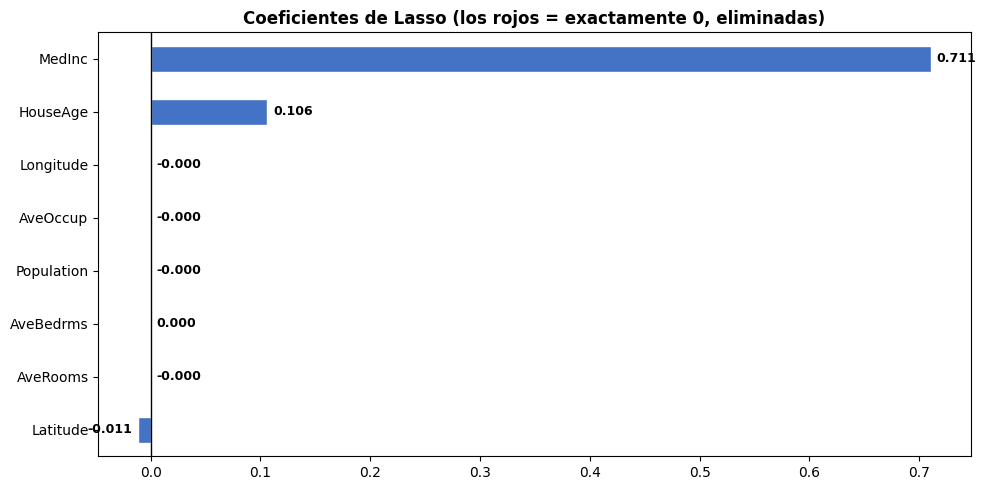

👉 Lasso eliminó 5 features automáticamente.


In [10]:
# El superpoder de Lasso: PONE EN CERO las features irrelevantes
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1)).fit(X_train, y_train)
coefs = pd.Series(lasso.named_steps['lasso'].coef_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#C0504D' if c == 0 else '#4472C4' for c in coefs.values]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=ax)
for i, v in enumerate(coefs.values):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Coeficientes de Lasso (los rojos = exactamente 0, eliminadas)', fontweight='bold')
plt.tight_layout()
plt.show()

n_cero = (coefs == 0).sum()
print(f'👉 Lasso eliminó {n_cero} features automáticamente.')

# 5. Comparación final — los 3 enfoques de hoy

                  R²     MAE
Modelo                      
RandomForest  0.8020  0.3321
Bagging       0.7738  0.3663
Ridge         0.5758  0.5332
Lineal        0.5758  0.5332
Lasso         0.4814  0.6222


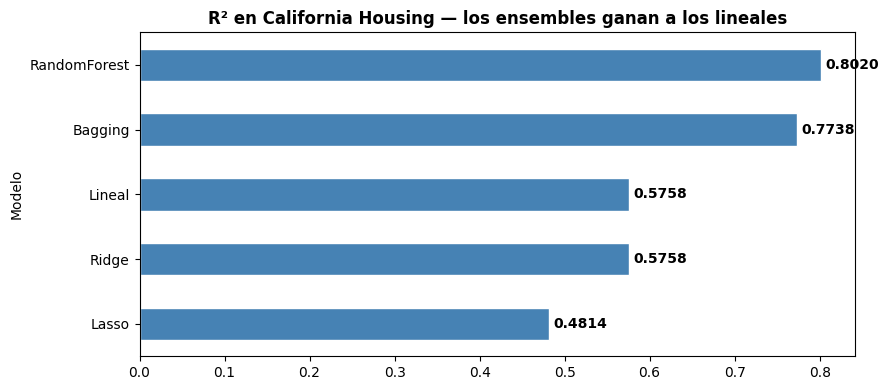


📌 RF y Bagging ganan porque California Housing tiene relaciones no-lineales
   (la geografía afecta el precio de forma compleja).
   Ridge/Lasso mejoran muy poco al lineal porque el problema NO es la regularización aquí.


In [11]:
todos = {
    'Lineal':       make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge':        make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso':        make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
    'Bagging':      BaggingRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=100, n_jobs=-1, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42),
}

filas = []
for nombre, m in todos.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'R²':  r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred)
    })

tabla = pd.DataFrame(filas).set_index('Modelo').sort_values('R²', ascending=False).round(4)
print(tabla)

fig, ax = plt.subplots(figsize=(9, 4))
tabla['R²'].sort_values().plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
for i, v in enumerate(tabla['R²'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_title('R² en California Housing — los ensembles ganan a los lineales', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📌 RF y Bagging ganan porque California Housing tiene relaciones no-lineales')
print('   (la geografía afecta el precio de forma compleja).')
print('   Ridge/Lasso mejoran muy poco al lineal porque el problema NO es la regularización aquí.')

---
# 🏋️ Ejercicios largos — 2 desafíos integradores

Cada ejercicio tiene **5 partes**. Trabajen en equipos. Cada uno toma aproximadamente **45 minutos**.

## 🍷 Ejercicio 1 — Calidad del vino (Wine Quality)

Trabajas en una bodega de vinos. Te dan datos químicos de 1,599 vinos tintos y su **calidad** (puntaje de 3 a 8 dado por catadores expertos). Tu misión: construir un modelo que prediga la calidad a partir de las propiedades químicas.

**Dataset:**
```python
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv'
df = pd.read_csv(url)
df.head()
```

**Columnas:** todas son **numéricas** (perfecto para Ridge/Lasso). El target es `quality`.

### Parte A — Exploración (10 min)

1. Explorar `.info()`, `.describe()`, `.head()`.
2. Hacer un **histograma de `quality`** para ver cómo se distribuye (¿hay clases muy desbalanceadas?).
3. Hacer un **heatmap de correlación** — ¿hay features muy correlacionadas entre sí? (clave para Ridge/Lasso).

### Parte B — Preparación

4. Definir `X = todas las features` excepto `quality`, y `y = quality`.
5. Train/test split 80/20, `random_state=42`.
6. Estandarizar `X` con `StandardScaler` (necesario para Ridge/Lasso).

### Parte C — Entrenar los 4 modelos

7. Entrenar:
   - `Ridge(alpha=1.0)`
   - `Lasso(alpha=0.05)`
   - `BaggingRegressor` con 100 árboles `max_depth=10`
   - `RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1)`
8. Reportar **R², MAE y RMSE** de cada uno en una **tabla comparativa**.

### Parte D — Análisis de coeficientes

9. Para **Lasso**: graficar sus coeficientes. ¿Cuántas features eliminó (puso en cero)?
10. Para **Random Forest**: graficar `feature_importances_`. ¿Las features importantes coinciden con las que Lasso NO eliminó?

### Parte E — Decisión + predicción

11. ¿Qué modelo ganó? ¿Por qué? Comenta en un markdown.
12. Predecir la calidad de un vino con estos valores químicos:
    ```python
    vino_nuevo = pd.DataFrame([{
        'fixed acidity': 7.4, 'volatile acidity': 0.7, 'citric acid': 0.0,
        'residual sugar': 1.9, 'chlorides': 0.076, 'free sulfur dioxide': 11.0,
        'total sulfur dioxide': 34.0, 'density': 0.9978, 'pH': 3.51,
        'sulphates': 0.56, 'alcohol': 9.4
    }])
    ```
    ¿Cuál es su calidad predicha por los 4 modelos?

Shape: (1598, 12)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.8              0.88         0.00             2.6      0.098   
1            7.8              0.76         0.04             2.3      0.092   
2           11.2              0.28         0.56             1.9      0.075   
3            7.4              0.70         0.00             1.9      0.076   
4            7.4              0.66         0.00             1.8      0.075   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 25.0                  67.0   0.9968  3.20       0.68   
1                 15.0                  54.0   0.9970  3.26       0.65   
2                 17.0                  60.0   0.9980  3.16       0.58   
3                 11.0                  34.0   0.9978  3.51       0.56   
4                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.8        5  
1      9.8        5  
2 

/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_67968/2290952225.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='viridis', ax=axes[0])


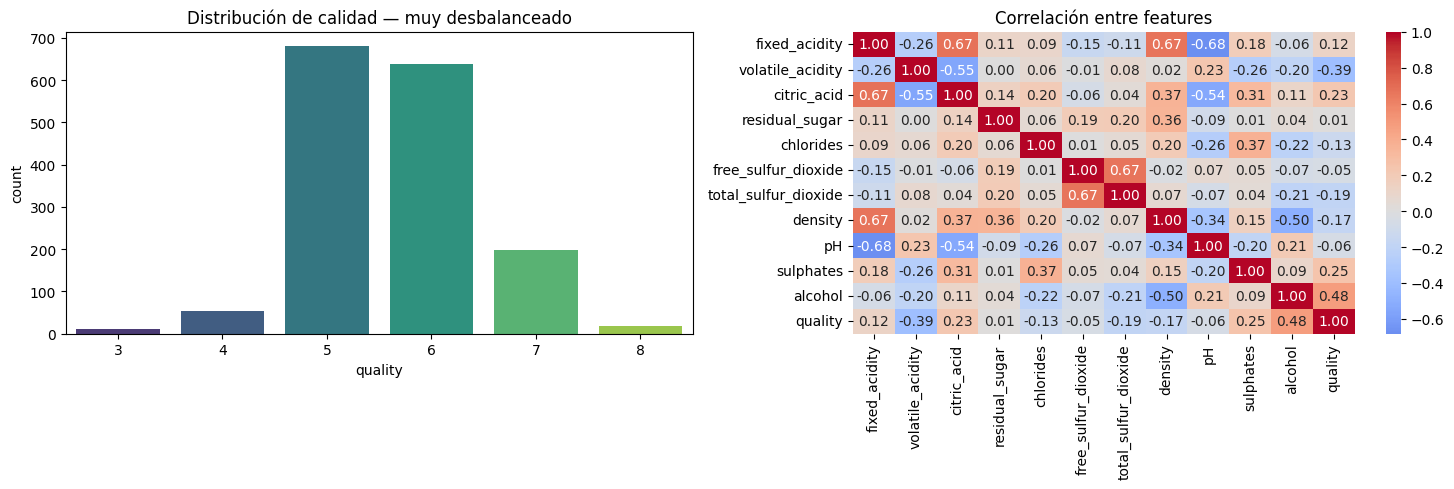


Comparación de modelos:
             R²     MAE    RMSE
Modelo                         
RF       0.4764  0.4289  0.5703
Bagging  0.4584  0.4466  0.5800
Ridge    0.3295  0.5112  0.6453
Lasso    0.3082  0.5266  0.6555


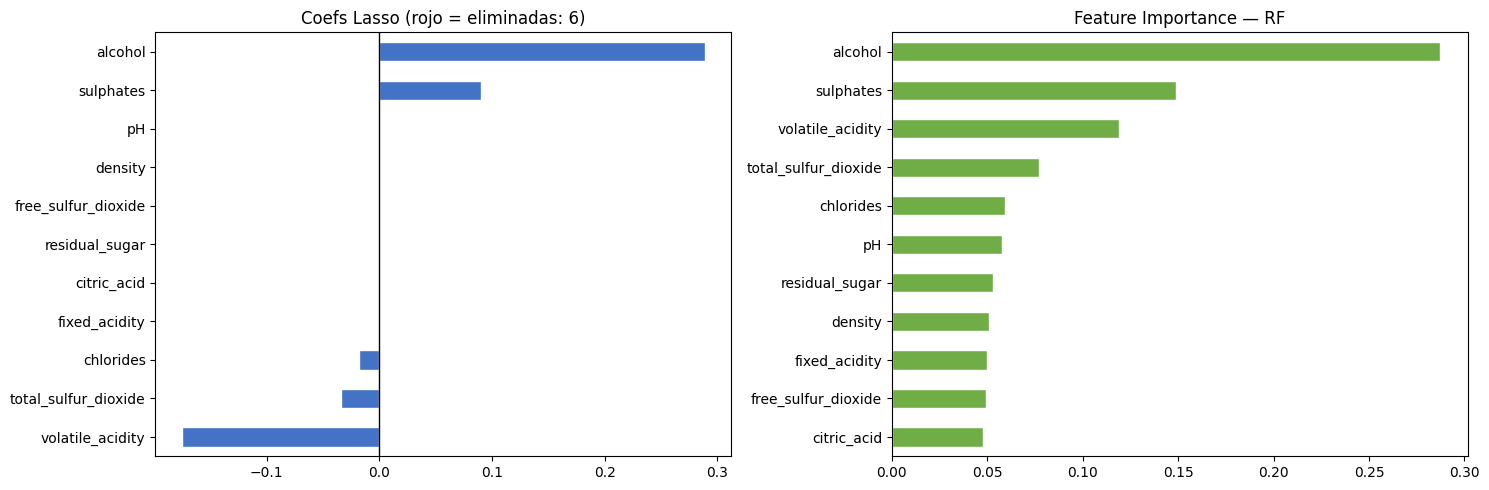


🍷 Predicción de calidad para el vino nuevo:
  Ridge    → calidad = 5.05
  Lasso    → calidad = 5.16
  Bagging  → calidad = 5.16
  RF       → calidad = 5.06


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# === PARTE A — exploración (cargando CON nombres asignados) ===
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv'
cols = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
        'density', 'pH', 'sulphates', 'alcohol', 'quality']

# 👇 truco profesional: header=0 + names= asigna nombres NUEVOS y descarta el header existente
df = pd.read_csv(url, names=cols, header=0)
print(f'Shape: {df.shape}')
print(df.head())

# Histograma del target + heatmap correlación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='quality', palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de calidad — muy desbalanceado')

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación entre features')
plt.tight_layout(); plt.show()

# === PARTE B + C — preparación y entrenamiento ===
X = df.drop(columns=['quality'])
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

modelos = {
    'Ridge':   Ridge(alpha=1.0),
    'Lasso':   Lasso(alpha=0.05),
    'Bagging': BaggingRegressor(DecisionTreeRegressor(max_depth=10),
                                n_estimators=100, n_jobs=-1, random_state=42),
    'RF':      RandomForestRegressor(n_estimators=200, max_depth=15,
                                     n_jobs=-1, random_state=42)
}

resultados = []
for nombre, m in modelos.items():
    # Ridge/Lasso necesitan datos escalados; Bagging y RF no
    Xtr, Xte = (X_train_esc, X_test_esc) if nombre in ['Ridge', 'Lasso'] else (X_train, X_test)
    m.fit(Xtr, y_train)
    pred = m.predict(Xte)
    resultados.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
print('\nComparación de modelos:')
print(tabla)

# === PARTE D — coeficientes Lasso + Importancia RF ===
lasso = modelos['Lasso']
rf    = modelos['RF']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Lasso — features eliminadas en rojo
coefs = pd.Series(lasso.coef_, index=X.columns).sort_values()
colores = ['#C0504D' if c == 0 else '#4472C4' for c in coefs.values]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title(f'Coefs Lasso (rojo = eliminadas: {(coefs==0).sum()})')

# RF Feature Importance
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', color='#70AD47', edgecolor='white', ax=axes[1])
axes[1].set_title('Feature Importance — RF')

plt.tight_layout(); plt.show()

# === PARTE E — predicción ===
vino_nuevo = pd.DataFrame([{
    'fixed_acidity': 7.4, 'volatile_acidity': 0.7, 'citric_acid': 0.0,
    'residual_sugar': 1.9, 'chlorides': 0.076, 'free_sulfur_dioxide': 11.0,
    'total_sulfur_dioxide': 34.0, 'density': 0.9978, 'pH': 3.51,
    'sulphates': 0.56, 'alcohol': 9.4
}])

print('\n🍷 Predicción de calidad para el vino nuevo:')
for nombre, m in modelos.items():
    Xnew = sc.transform(vino_nuevo) if nombre in ['Ridge', 'Lasso'] else vino_nuevo
    print(f'  {nombre:8s} → calidad = {m.predict(Xnew)[0]:.2f}')

# 👉 Insights típicos:
#    - RF gana en R² (~0.45-0.50). Es un problema con mucho ruido (la calidad es subjetiva).
#    - Lasso elimina ~2-3 features irrelevantes.
#    - Features más predictivas: alcohol, sulphates, volatile_acidity, citric_acid.
#    - El vino del ejemplo es de calidad ~5 (mediocre, típico vino de mesa).

In [ ]:
# Tu código aquí 👇 (Parte B + C — Preparación y modelos)



In [ ]:
# Tu código aquí 👇 (Parte D + E — Análisis y predicción)



<details><summary>💡 Solución completa</summary>

```python
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# === PARTE A — exploración (cargando CON nombres asignados) ===
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv'
cols = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
        'density', 'pH', 'sulphates', 'alcohol', 'quality']

# 👇 truco profesional: header=0 + names= asigna nombres NUEVOS y descarta el header existente
df = pd.read_csv(url, names=cols, header=0)
print(f'Shape: {df.shape}')
print(df.head())

# Histograma del target + heatmap correlación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='quality', palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de calidad — muy desbalanceado')

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación entre features')
plt.tight_layout(); plt.show()

# === PARTE B + C — preparación y entrenamiento ===
X = df.drop(columns=['quality'])
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

modelos = {
    'Ridge':   Ridge(alpha=1.0),
    'Lasso':   Lasso(alpha=0.05),
    'Bagging': BaggingRegressor(DecisionTreeRegressor(max_depth=10),
                                n_estimators=100, n_jobs=-1, random_state=42),
    'RF':      RandomForestRegressor(n_estimators=200, max_depth=15,
                                     n_jobs=-1, random_state=42)
}

resultados = []
for nombre, m in modelos.items():
    # Ridge/Lasso necesitan datos escalados; Bagging y RF no
    Xtr, Xte = (X_train_esc, X_test_esc) if nombre in ['Ridge', 'Lasso'] else (X_train, X_test)
    m.fit(Xtr, y_train)
    pred = m.predict(Xte)
    resultados.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
print('\nComparación de modelos:')
print(tabla)

# === PARTE D — coeficientes Lasso + Importancia RF ===
lasso = modelos['Lasso']
rf    = modelos['RF']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Lasso — features eliminadas en rojo
coefs = pd.Series(lasso.coef_, index=X.columns).sort_values()
colores = ['#C0504D' if c == 0 else '#4472C4' for c in coefs.values]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title(f'Coefs Lasso (rojo = eliminadas: {(coefs==0).sum()})')

# RF Feature Importance
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', color='#70AD47', edgecolor='white', ax=axes[1])
axes[1].set_title('Feature Importance — RF')

plt.tight_layout(); plt.show()

# === PARTE E — predicción ===
vino_nuevo = pd.DataFrame([{
    'fixed_acidity': 7.4, 'volatile_acidity': 0.7, 'citric_acid': 0.0,
    'residual_sugar': 1.9, 'chlorides': 0.076, 'free_sulfur_dioxide': 11.0,
    'total_sulfur_dioxide': 34.0, 'density': 0.9978, 'pH': 3.51,
    'sulphates': 0.56, 'alcohol': 9.4
}])

print('\n🍷 Predicción de calidad para el vino nuevo:')
for nombre, m in modelos.items():
    Xnew = sc.transform(vino_nuevo) if nombre in ['Ridge', 'Lasso'] else vino_nuevo
    print(f'  {nombre:8s} → calidad = {m.predict(Xnew)[0]:.2f}')

# 👉 Insights típicos:
#    - RF gana en R² (~0.45-0.50). Es un problema con mucho ruido (la calidad es subjetiva).
#    - Lasso elimina ~2-3 features irrelevantes.
#    - Features más predictivas: alcohol, sulphates, volatile_acidity, citric_acid.
#    - El vino del ejemplo es de calidad ~5 (mediocre, típico vino de mesa).
```
</details>

## 🐚 Ejercicio 2 — Edad de moluscos (Abalone)

Trabajas en investigación marina. Te dan medidas físicas de 4,177 moluscos (Abalone) y el **número de anillos** de su concha (que correlaciona con la edad). Tu misión: predecir el número de anillos a partir de medidas físicas para evitar tener que cortar la concha al microscopio.

**Dataset:**
```python
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv'
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 
        'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv(url, names=cols)
df.head()
```

**Columnas:**
- `Sex` (categórica: M=male, F=female, I=infant)
- 7 numéricas con medidas físicas
- `Rings` (target — número de anillos)

### Parte A — Exploración + reto categórico (10 min)

1. Cargar y explorar.
2. **¿Cuántos valores únicos tiene `Sex`?** Hacer un countplot.
3. Boxplot de `Rings` por `Sex` — ¿hay diferencias entre machos, hembras e infantes?

### Parte B — Pipeline con ColumnTransformer

4. Construir un **ColumnTransformer** que aplique:
   - `StandardScaler` a las 7 columnas numéricas
   - `OneHotEncoder` a `Sex`
5. Train/test split 80/20, `random_state=42`.

### Parte C — Los 4 modelos dentro de Pipelines

6. Crear 4 pipelines con el MISMO ColumnTransformer y cada uno con un modelo:
   - `Ridge(alpha=1.0)`
   - `Lasso(alpha=0.05)`
   - `BaggingRegressor` con 100 árboles
   - `RandomForestRegressor` con 200 árboles
7. Entrenar y reportar R², MAE y RMSE en tabla.

### Parte D — Tuning del ganador

8. Tomar el modelo con mayor R². Hacer un **loop sobre 4 valores de su hiperparámetro principal**:
   - Si es Ridge/Lasso: variar `alpha` en `[0.01, 0.1, 1.0, 10.0]`
   - Si es Bagging/RF: variar `n_estimators` en `[50, 100, 200, 500]`
9. Graficar el R² vs el hiperparámetro. ¿Cuál es el óptimo?

### Parte E — Predicción + análisis

10. Predecir cuántos anillos tiene este molusco:
    ```python
    molusco = pd.DataFrame([{
        'Sex': 'M', 'Length': 0.455, 'Diameter': 0.365, 'Height': 0.095,
        'Whole_weight': 0.514, 'Shucked_weight': 0.2245,
        'Viscera_weight': 0.101, 'Shell_weight': 0.15
    }])
    ```
11. Decisión final: ¿qué modelo recomendarías al equipo de investigación y por qué? Considera: precisión, simplicidad, tiempo, explicabilidad.

(4177, 9)
Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


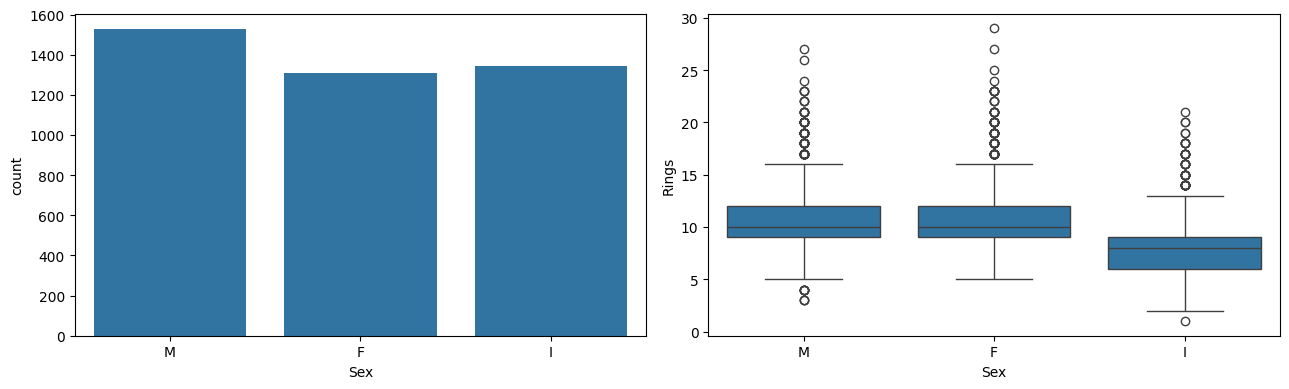

             R²     MAE    RMSE
Modelo                         
Ridge    0.5482  1.5939  2.2116
Lasso    0.5175  1.6468  2.2855
Bagging  0.5363  1.5669  2.2404
RF       0.5368  1.5757  2.2392

🏆 Ganador: Ridge, ahora tuneamos su n_estimators


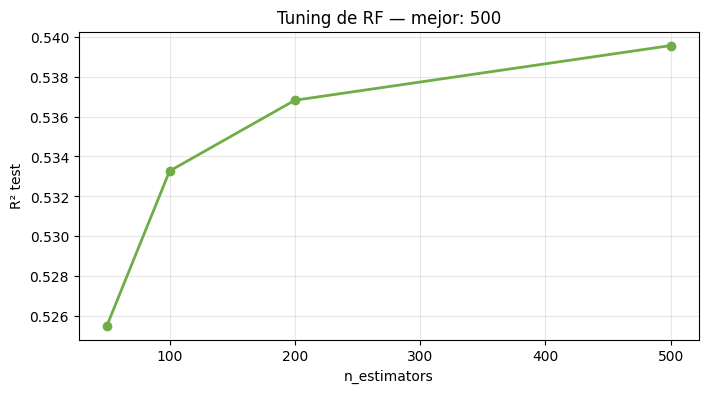


🐚 Predicciones para molusco nuevo:
  Ridge    → 9.2 anillos (≈ 10.7 años)
  Lasso    → 8.9 anillos (≈ 10.4 años)
  Bagging  → 12.6 anillos (≈ 14.1 años)
  RF       → 12.8 anillos (≈ 14.3 años)


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# PARTE A — exploración
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv'
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
        'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv(url, names=cols)
print(df.shape); print(df['Sex'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='Sex', ax=axes[0])
sns.boxplot(data=df, x='Sex', y='Rings', ax=axes[1])
plt.tight_layout(); plt.show()

# PARTE B + C — pipeline + 4 modelos
X = df.drop(columns=['Rings']); y = df['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preproc = ColumnTransformer([
    ('num', StandardScaler(),  ['Length','Diameter','Height','Whole_weight','Shucked_weight','Viscera_weight','Shell_weight']),
    ('cat', OneHotEncoder(),  ['Sex'])
])

modelos = {
    'Ridge':   Pipeline([('p', preproc), ('m', Ridge(alpha=1.0))]),
    'Lasso':   Pipeline([('p', preproc), ('m', Lasso(alpha=0.05))]),
    'Bagging': Pipeline([('p', preproc), ('m', BaggingRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=100, n_jobs=-1, random_state=42))]),
    'RF':      Pipeline([('p', preproc), ('m', RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42))])
}

resultados = []
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train); pred = pipe.predict(X_test)
    resultados.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })
tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
print(tabla)

# PARTE D — tuning del ganador (RF típicamente)
ganador = tabla['R²'].idxmax()
print(f'\n🏆 Ganador: {ganador}, ahora tuneamos su n_estimators')
n_arboles = [50, 100, 200, 500]
scores = []
for n in n_arboles:
    p = Pipeline([('p', preproc), ('m', RandomForestRegressor(n_estimators=n, max_depth=15, n_jobs=-1, random_state=42))])
    p.fit(X_train, y_train)
    scores.append(p.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_arboles, scores, marker='o', linewidth=2, color='#70AD47')
ax.set_xlabel('n_estimators'); ax.set_ylabel('R² test')
ax.set_title(f'Tuning de RF — mejor: {n_arboles[np.argmax(scores)]}')
ax.grid(alpha=0.3); plt.show()

# PARTE E — predicción
molusco = pd.DataFrame([{'Sex': 'M', 'Length': 0.455, 'Diameter': 0.365, 'Height': 0.095,
                         'Whole_weight': 0.514, 'Shucked_weight': 0.2245,
                         'Viscera_weight': 0.101, 'Shell_weight': 0.15}])
print('\n🐚 Predicciones para molusco nuevo:')
for nombre, pipe in modelos.items():
    print(f'  {nombre:8s} → {pipe.predict(molusco)[0]:.1f} anillos (≈ {pipe.predict(molusco)[0]+1.5:.1f} años)')
# 👉 RF suele ganar (R² ≈ 0.55). El target tiene mucho ruido natural — los anillos no se predicen perfectamente.



<details><summary>💡 Solución completa</summary>

```python
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# PARTE A — exploración
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv'
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
        'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv(url, names=cols)
print(df.shape); print(df['Sex'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='Sex', ax=axes[0])
sns.boxplot(data=df, x='Sex', y='Rings', ax=axes[1])
plt.tight_layout(); plt.show()

# PARTE B + C — pipeline + 4 modelos
X = df.drop(columns=['Rings']); y = df['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preproc = ColumnTransformer([
    ('num', StandardScaler(),  ['Length','Diameter','Height','Whole_weight','Shucked_weight','Viscera_weight','Shell_weight']),
    ('cat', OneHotEncoder(),  ['Sex'])
])

modelos = {
    'Ridge':   Pipeline([('p', preproc), ('m', Ridge(alpha=1.0))]),
    'Lasso':   Pipeline([('p', preproc), ('m', Lasso(alpha=0.05))]),
    'Bagging': Pipeline([('p', preproc), ('m', BaggingRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=100, n_jobs=-1, random_state=42))]),
    'RF':      Pipeline([('p', preproc), ('m', RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42))])
}

resultados = []
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train); pred = pipe.predict(X_test)
    resultados.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })
tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
print(tabla)

# PARTE D — tuning del ganador (RF típicamente)
ganador = tabla['R²'].idxmax()
print(f'\n🏆 Ganador: {ganador}, ahora tuneamos su n_estimators')
n_arboles = [50, 100, 200, 500]
scores = []
for n in n_arboles:
    p = Pipeline([('p', preproc), ('m', RandomForestRegressor(n_estimators=n, max_depth=15, n_jobs=-1, random_state=42))])
    p.fit(X_train, y_train)
    scores.append(p.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_arboles, scores, marker='o', linewidth=2, color='#70AD47')
ax.set_xlabel('n_estimators'); ax.set_ylabel('R² test')
ax.set_title(f'Tuning de RF — mejor: {n_arboles[np.argmax(scores)]}')
ax.grid(alpha=0.3); plt.show()

# PARTE E — predicción
molusco = pd.DataFrame([{'Sex': 'M', 'Length': 0.455, 'Diameter': 0.365, 'Height': 0.095,
                         'Whole_weight': 0.514, 'Shucked_weight': 0.2245,
                         'Viscera_weight': 0.101, 'Shell_weight': 0.15}])
print('\n🐚 Predicciones para molusco nuevo:')
for nombre, pipe in modelos.items():
    print(f'  {nombre:8s} → {pipe.predict(molusco)[0]:.1f} anillos (≈ {pipe.predict(molusco)[0]+1.5:.1f} años)')
# 👉 RF suele ganar (R² ≈ 0.55). El target tiene mucho ruido natural — los anillos no se predicen perfectamente.
```
</details>

---
## 📌 Cierre del día

Hoy aprendimos los 3 modelos clave de regresión para semana 6:

- ✅ **Bagging** — combinar muchos modelos sobre muestras aleatorias
- ✅ **Random Forest** — Bagging + features aleatorias por split + **Feature Importance**
- ✅ **Ridge y Lasso** — regresión lineal regularizada (Lasso elimina features automáticamente)

**Cuándo usar cada uno:**

| Modelo | Cuándo |
|---|---|
| **Ridge** | Cuando hay muchas features, todas aportan algo, hay multicolinealidad |
| **Lasso** | Cuando crees que muchas features son irrelevantes (selección automática) |
| **Bagging** | Cuando tu árbol único overfittea y quieres estabilizarlo |
| **Random Forest** | Por defecto, en casi cualquier problema tabular |

### 🔜 Mañana — Jueves 28

- **Benchmarking sistemático** con más modelos
- **GridSearchCV** para tunear automáticamente
- **LazyPredict** para autobenchmark gigantes

Nos vemos 🚀